# Primary Market Walk-Forward Analysis — PL Platinum Futures

**Course:** MATH GR5360 Mathematical Methods in Financial Price Analysis  
**Project component:** Primary-market algorithm and performance analysis  
**Market:** PL / Platinum Futures  

This notebook provides a formal analysis of the primary-market walk-forward optimization results generated by the Channel WithDDControl implementation. It audits the generated output files, computes out-of-sample performance and risk diagnostics, evaluates parameter stability, and exports presentation-ready tables and figures.

## 1. Notebook Setup

Run this notebook from the repository root directory, the same level as `src/`, `scripts/`, and `results/`. The path detection code below also handles the common case where a zipped folder extracts into `results/results/`.

In [24]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["savefig.dpi"] = 180
plt.rcParams["font.size"] = 11

ROOT = Path.cwd()
FIG_DIR = ROOT / "figures" / "primary_market"
TABLE_DIR = ROOT / "tables" / "primary_market"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

CANDIDATE_RESULT_DIRS = [
    ROOT / "results" / "pl_wfo_full",
    ROOT / "results" / "results" / "pl_wfo_full",
    ROOT / "pl_wfo_full",
]

RESULT_DIR = next((p for p in CANDIDATE_RESULT_DIRS if p.exists()), None)
if RESULT_DIR is None:
    raise FileNotFoundError(
        "Could not find PL WFO output directory. Expected one of: "
        + ", ".join(str(p) for p in CANDIDATE_RESULT_DIRS)
    )

print(f"Using result directory: {RESULT_DIR}")
print(f"Figures will be saved to: {FIG_DIR}")
print(f"Tables will be saved to: {TABLE_DIR}")

Using result directory: /Users/always/Desktop/results/pl_wfo_full
Figures will be saved to: /Users/always/Desktop/results/figures/primary_market
Tables will be saved to: /Users/always/Desktop/results/tables/primary_market


## 2. Load Walk-Forward Output Files

The primary analysis uses three output files:

- `wfo_os_equity.csv`: bar-level out-of-sample equity, P&L, trades, and end-of-bar position.
- `wfo_os_trades.csv`: reconstructed trade table for the out-of-sample period.
- `wfo_quarter_params.csv`: per-quarter in-sample optimization results and out-of-sample quarter performance.

In [25]:
equity_path = RESULT_DIR / "wfo_os_equity.csv"
trades_path = RESULT_DIR / "wfo_os_trades.csv"
params_path = RESULT_DIR / "wfo_quarter_params.csv"

required_files = {
    "OOS equity curve": equity_path,
    "OOS trade table": trades_path,
    "Quarterly optimal parameters": params_path,
}

for label, path in required_files.items():
    status = "READY" if path.exists() else "REQUIRED"
    print(f"{label:32s}: {status} — {path}")

if not all(p.exists() for p in required_files.values()):
    required_paths = [str(p) for p in required_files.values() if not p.exists()]
    raise FileNotFoundError("Required output files are not available in the expected directory: " + ", ".join(required_paths))

equity = pd.read_csv(equity_path)
trades = pd.read_csv(trades_path)
params = pd.read_csv(params_path)

# Standardize dates and sort.
equity["DateTime"] = pd.to_datetime(equity["DateTime"])
equity = equity.sort_values("DateTime").reset_index(drop=True)
trades["entry_time"] = pd.to_datetime(trades["entry_time"])
trades["exit_time"] = pd.to_datetime(trades["exit_time"])
trades = trades.sort_values("entry_time").reset_index(drop=True)

# Useful derived columns.
equity["RunningMax"] = equity["Equity"].cummax()
equity["Drawdown"] = equity["Equity"] - equity["RunningMax"]
equity["DrawdownPct"] = equity["Equity"] / equity["RunningMax"] - 1
trades["holding_bars"] = trades["exit_bar"] - trades["entry_bar"]
trades["holding_minutes"] = (trades["exit_time"] - trades["entry_time"]).dt.total_seconds() / 60
trades["side_label"] = trades["side"].map({1: "Long", -1: "Short"}).fillna("Other")

params["q_period"] = pd.PeriodIndex(params["q_label"], freq="Q")
params["q_start"] = params["q_period"].dt.start_time
params["q_end"] = params["q_period"].dt.end_time
params["os_npdd"] = params["os_profit"] / params["os_dd"].abs().replace(0, np.nan)
params["param_turnover_L"] = params["best_L"].diff().abs()
params["param_turnover_S"] = params["best_S"].diff().abs()

display(equity.head())
display(trades.head())
display(params.head())

OOS equity curve                : READY — /Users/always/Desktop/results/pl_wfo_full/wfo_os_equity.csv
OOS trade table                 : READY — /Users/always/Desktop/results/pl_wfo_full/wfo_os_trades.csv
Quarterly optimal parameters    : READY — /Users/always/Desktop/results/pl_wfo_full/wfo_quarter_params.csv


,DateTime,Equity,PnL,Trades,PosEnd,RunningMax,Drawdown,DrawdownPct
0,2012-01-03 08:25:00,100000.0,0.0,0.0,0,100000.0,0.0,0.0
1,2012-01-03 08:30:00,100000.0,0.0,0.0,0,100000.0,0.0,0.0
2,2012-01-03 08:35:00,100000.0,0.0,0.0,0,100000.0,0.0,0.0
3,2012-01-03 08:40:00,100000.0,0.0,0.0,0,100000.0,0.0,0.0
4,2012-01-03 08:45:00,100000.0,0.0,0.0,0,100000.0,0.0,0.0


,entry_bar,exit_bar,entry_time,exit_time,side,pnl,holding_bars,holding_minutes,side_label
0,570,577,2012-01-17 08:25:00,2012-01-17 09:00:00,1,1052.550,7,35.0,Long
1,684,690,2012-01-19 08:25:00,2012-01-19 08:55:00,1,-437.925,6,30.0,Long
2,798,799,2012-01-23 08:25:00,2012-01-23 08:30:00,1,253.125,1,5.0,Long
3,818,845,2012-01-23 10:05:00,2012-01-23 12:20:00,1,89.975,27,135.0,Long
4,963,967,2012-01-25 12:40:00,2012-01-25 13:00:00,1,295.775,4,20.0,Long


,q_label,is_lo,is_hi,os_lo,os_hi,best_L,best_S,is_profit,is_dd,is_npdd,is_trades,os_profit,os_dd,os_trades,q_period,q_start,q_end,os_npdd,param_turnover_L,param_turnover_S
0,2012Q1,3648,62515,62516,66163,1240,0.005,81192.025,-2820.200,28.789456,344.0,2299.575,-2180.05,17.0,2012Q1,2012-01-01,2012-03-31 23:59:59.999999999,1.054827,NaN,NaN
1,2012Q2,7239,66163,66164,69811,1990,0.008,59815.960,-2717.720,22.009611,170.0,-1104.120,-2830.52,16.0,2012Q2,2012-04-01,2012-06-30 23:59:59.999999999,-0.390077,750.0,0.003
2,2012Q3,10944,69811,69812,73516,3870,0.013,49932.505,-3032.835,16.463970,83.0,6535.575,-1448.04,4.0,2012Q3,2012-07-01,2012-09-30 23:59:59.999999999,4.513394,1880.0,0.005
3,2012Q4,14706,73516,73517,77221,570,0.008,65037.000,-5003.280,12.998873,304.0,5018.440,-1710.28,13.0,2012Q4,2012-10-01,2012-12-31 23:59:59.999999999,2.934280,3300.0,0.005
4,2013Q1,18398,77221,77222,80755,570,0.008,65064.720,-5003.280,13.004413,287.0,2841.960,-2988.28,15.0,2013Q1,2013-01-01,2013-03-31 23:59:59.999999999,0.951035,0.0,0.000


## 3. Repository Output Audit

This section checks whether the current primary-market output folder contains the core files needed for the project presentation. It does not replace separate validation or secondary-market analysis; it verifies that the primary PL WFO result package is complete enough for performance analysis.

In [26]:
audit_rows = [
    ("Bar-level OOS equity curve", equity_path.exists(), "wfo_os_equity.csv"),
    ("OOS trade-by-trade table", trades_path.exists(), "wfo_os_trades.csv"),
    ("Per-quarter optimal parameter log", params_path.exists(), "wfo_quarter_params.csv"),
    ("Drawdown series derivable from equity", "Drawdown" in equity.columns, "computed in notebook"),
    ("Performance statistics derivable from outputs", len(equity) > 0 and len(trades) > 0, "computed in notebook"),
]

audit = pd.DataFrame(audit_rows, columns=["Requirement / Output", "Available", "Source"])
audit["Available"] = audit["Available"].map({True: "Yes", False: "No"})
audit.to_csv(TABLE_DIR / "output_audit.csv", index=False)
display(audit)

,Requirement / Output,Available,Source
0,Bar-level OOS equity curve,Yes,wfo_os_equity.csv
1,OOS trade-by-trade table,Yes,wfo_os_trades.csv
2,Per-quarter optimal parameter log,Yes,wfo_quarter_params.csv
3,Drawdown series derivable from equity,Yes,computed in notebook
4,Performance statistics derivable from outputs,Yes,computed in notebook


## 4. Data Integrity Checks

Before interpreting the performance, the notebook checks the continuity and internal consistency of the outputs. These checks are useful for identifying accidental file mix-ups, duplicate timestamps, or non-monotonic equity records.

In [27]:
integrity = {
    "equity_rows": len(equity),
    "trade_rows": len(trades),
    "quarter_rows": len(params),
    "equity_start": equity["DateTime"].min(),
    "equity_end": equity["DateTime"].max(),
    "duplicate_equity_timestamps": int(equity["DateTime"].duplicated().sum()),
    "equity_time_monotonic": bool(equity["DateTime"].is_monotonic_increasing),
    "equity_contains_na": bool(equity["Equity"].isna().any()),
    "pnl_contains_na": bool(equity["PnL"].isna().any()),
    "initial_equity": float(equity["Equity"].iloc[0]),
    "final_equity": float(equity["Equity"].iloc[-1]),
    "sum_bar_pnl": float(equity["PnL"].sum()),
    "final_minus_initial": float(equity["Equity"].iloc[-1] - equity["Equity"].iloc[0]),
}

integrity_df = pd.DataFrame(list(integrity.items()), columns=["Check", "Value"])
integrity_df.to_csv(TABLE_DIR / "data_integrity_checks.csv", index=False)
display(integrity_df)

,Check,Value
0,equity_rows,209428
1,trade_rows,620
2,quarter_rows,57
3,equity_start,2012-01-03 08:25:00
4,equity_end,2026-03-31 13:05:00
5,duplicate_equity_timestamps,0
6,equity_time_monotonic,True
7,equity_contains_na,False
8,pnl_contains_na,False
9,initial_equity,100000.0


## 5. Out-of-Sample Performance Summary

The main performance table is computed directly from the fully out-of-sample equity curve and the reconstructed trade table. The strategy is evaluated on total profit, drawdown, return-to-drawdown, trade count, win rate, payoff asymmetry, and profit factor.

In [28]:
def safe_div(a, b):
    return np.nan if b == 0 or pd.isna(b) else a / b

initial_equity = float(equity["Equity"].iloc[0])
final_equity = float(equity["Equity"].iloc[-1])
total_profit = final_equity - initial_equity
worst_dd = float(equity["Drawdown"].min())
worst_dd_pct = float(equity["DrawdownPct"].min())
np_over_dd = safe_div(total_profit, abs(worst_dd))

# Daily return series from last available intraday equity in each calendar day.
daily_equity = equity.set_index("DateTime")["Equity"].resample("1D").last().dropna()
daily_pnl = daily_equity.diff().dropna()
daily_ret = daily_equity.pct_change().dropna()
calendar_days = max((daily_equity.index[-1] - daily_equity.index[0]).days, 1)
years = calendar_days / 365.25
cagr = (final_equity / initial_equity) ** (1 / years) - 1 if years > 0 and initial_equity > 0 else np.nan
ann_vol = daily_ret.std(ddof=1) * np.sqrt(252) if len(daily_ret) > 1 else np.nan
ann_sharpe = daily_ret.mean() / daily_ret.std(ddof=1) * np.sqrt(252) if daily_ret.std(ddof=1) != 0 else np.nan
calmar = safe_div(cagr, abs(worst_dd_pct))

n_trades = len(trades)
winners = trades[trades["pnl"] > 0]
losers = trades[trades["pnl"] < 0]
gross_profit = winners["pnl"].sum()
gross_loss = losers["pnl"].sum()
profit_factor = safe_div(gross_profit, abs(gross_loss))
expectancy = trades["pnl"].mean() if n_trades else np.nan
median_trade = trades["pnl"].median() if n_trades else np.nan
win_rate = len(winners) / n_trades if n_trades else np.nan
avg_winner = winners["pnl"].mean() if len(winners) else np.nan
avg_loser = losers["pnl"].mean() if len(losers) else np.nan
payoff_ratio = safe_div(avg_winner, abs(avg_loser))

summary = pd.DataFrame({
    "Metric": [
        "Market", "OOS start", "OOS end", "Number of OOS quarters",
        "Initial equity", "Final equity", "Total OOS profit", "Worst drawdown", "Worst drawdown (%)",
        "Net Profit / Max Drawdown", "CAGR", "Annualized volatility", "Annualized Sharpe", "Calmar ratio",
        "Number of trades", "Win rate", "Average trade P&L", "Median trade P&L",
        "Average winner", "Average loser", "Payoff ratio", "Profit factor"
    ],
    "Value": [
        "PL / Platinum Futures", equity["DateTime"].min().strftime("%Y-%m-%d"), equity["DateTime"].max().strftime("%Y-%m-%d"), len(params),
        initial_equity, final_equity, total_profit, worst_dd, worst_dd_pct,
        np_over_dd, cagr, ann_vol, ann_sharpe, calmar,
        n_trades, win_rate, expectancy, median_trade,
        avg_winner, avg_loser, payoff_ratio, profit_factor
    ]
})

summary_display = summary.copy()
summary_display["Value"] = summary_display["Value"].apply(
    lambda x: f"{x:,.4f}" if isinstance(x, (float, np.floating)) else x
)
summary.to_csv(TABLE_DIR / "performance_summary_raw.csv", index=False)
summary_display.to_csv(TABLE_DIR / "performance_summary_formatted.csv", index=False)
display(summary_display)

,Metric,Value
0,Market,PL / Platinum Futures
1,OOS start,2012-01-03
2,OOS end,2026-03-31
3,Number of OOS quarters,57
4,Initial equity,"100,000.0000"
5,Final equity,"200,828.1900"
6,Total OOS profit,"100,828.1900"
7,Worst drawdown,"-10,740.0500"
8,Worst drawdown (%),-0.0753
9,Net Profit / Max Drawdown,9.3881


## 6. Equity Curve and Drawdown Diagnostics

The equity curve evaluates the fully out-of-sample performance obtained by applying each quarter's optimized parameters to the following quarter only. The drawdown curve provides the corresponding downside path.

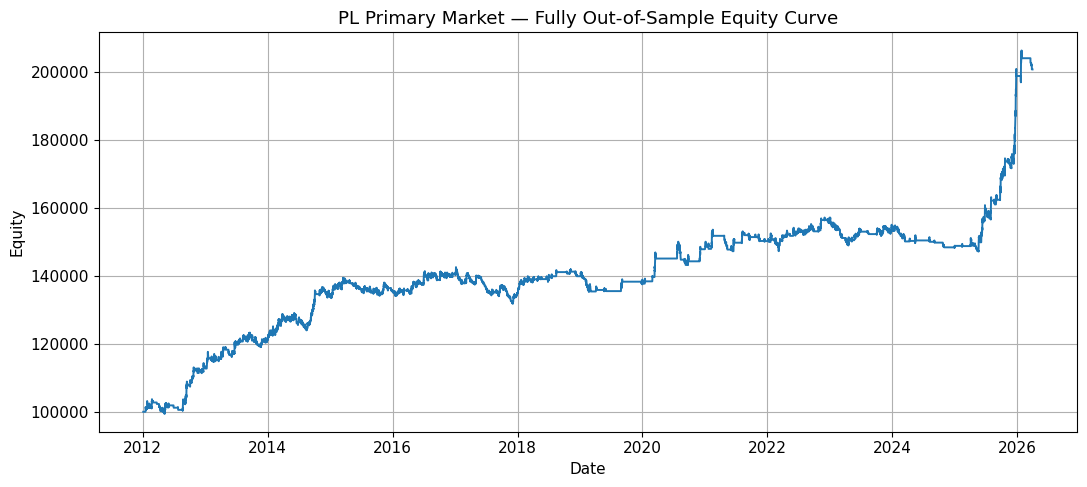

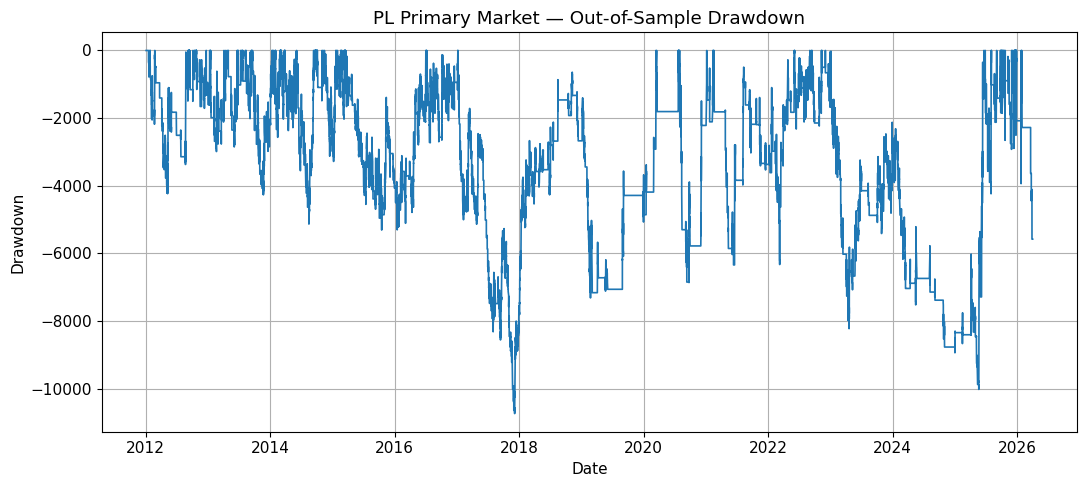

In [29]:
fig, ax = plt.subplots()
ax.plot(equity["DateTime"], equity["Equity"], linewidth=1.4)
ax.set_title("PL Primary Market — Fully Out-of-Sample Equity Curve")
ax.set_xlabel("Date")
ax.set_ylabel("Equity")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_oos_equity_curve.png")
plt.show()

fig, ax = plt.subplots()
ax.plot(equity["DateTime"], equity["Drawdown"], linewidth=1.2)
ax.set_title("PL Primary Market — Out-of-Sample Drawdown")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_oos_drawdown_curve.png")
plt.show()

## 7. Quarterly Out-of-Sample Performance

Quarterly results reveal whether performance is concentrated in a small number of periods or broadly distributed across the walk-forward sample.

,q_label,q_start,os_profit,os_dd,os_npdd,os_trades,best_L,best_S,is_npdd,is_npdd_rank,os_profit_rank
0,2012Q1,2012-01-01,2299.575,-2180.050,1.054827,17.0,1240,0.005,28.789456,1.000000,0.684211
1,2012Q2,2012-04-01,-1104.120,-2830.520,-0.390077,16.0,1990,0.008,22.009611,0.982456,0.210526
2,2012Q3,2012-07-01,6535.575,-1448.040,4.513394,4.0,3870,0.013,16.463970,0.912281,0.929825
3,2012Q4,2012-10-01,5018.440,-1710.280,2.934280,13.0,570,0.008,12.998873,0.736842,0.877193
4,2013Q1,2013-01-01,2841.960,-2988.280,0.951035,15.0,570,0.008,13.004413,0.754386,0.736842
5,2013Q2,2013-04-01,4167.360,-2852.120,1.461145,23.0,520,0.008,13.408221,0.789474,0.842105
6,2013Q3,2013-07-01,1189.920,-2365.680,0.502993,17.0,510,0.008,12.786432,0.719298,0.543860
7,2013Q4,2013-10-01,237.480,-3529.800,0.067279,20.0,510,0.008,11.766587,0.666667,0.438596
8,2014Q1,2014-01-01,6417.605,-2568.100,2.498970,6.0,510,0.017,13.508234,0.807018,0.912281
9,2014Q2,2014-04-01,-1291.485,-3554.515,-0.363336,8.5,510,0.017,14.534810,0.859649,0.157895


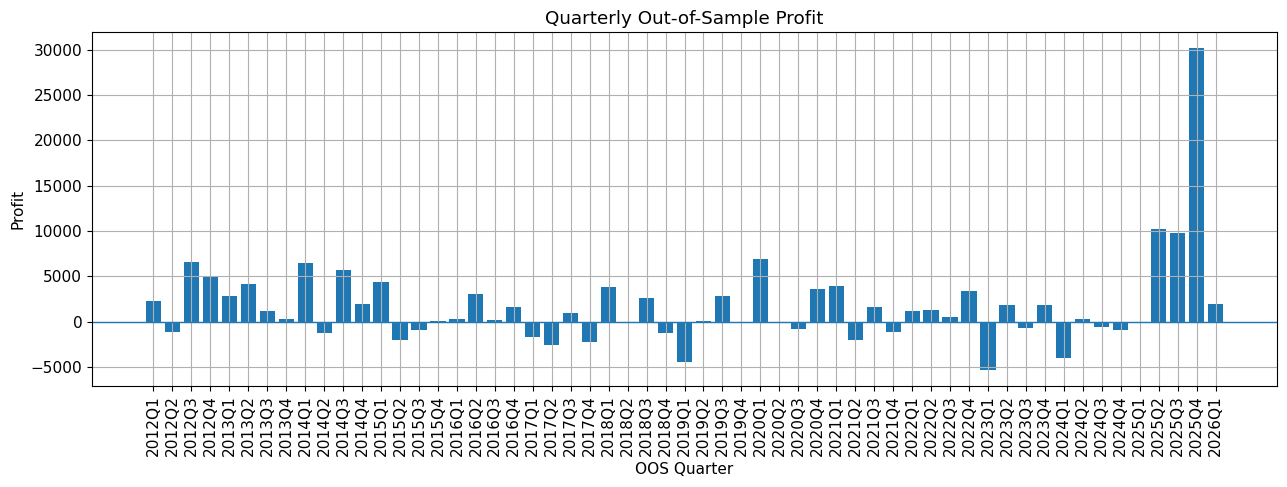

,Metric,Value
0,Positive OOS quarters,36
1,Negative OOS quarters,20
2,Average quarterly OOS profit,1768.915614
3,Median quarterly OOS profit,953.04
4,Best quarter,2025Q4
5,Worst quarter,2023Q1
6,Average trades per quarter,10.894737


In [30]:
quarterly = params[["q_label", "q_start", "os_profit", "os_dd", "os_npdd", "os_trades", "best_L", "best_S", "is_npdd"]].copy()
quarterly["is_npdd_rank"] = quarterly["is_npdd"].rank(pct=True)
quarterly["os_profit_rank"] = quarterly["os_profit"].rank(pct=True)
quarterly.to_csv(TABLE_DIR / "quarterly_wfo_summary.csv", index=False)

display(quarterly.head(10))

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(quarterly["q_label"], quarterly["os_profit"])
ax.axhline(0, linewidth=1)
ax.set_title("Quarterly Out-of-Sample Profit")
ax.set_xlabel("OOS Quarter")
ax.set_ylabel("Profit")
ax.tick_params(axis="x", rotation=90)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_quarterly_oos_profit.png")
plt.show()

quarterly_stats = pd.DataFrame({
    "Metric": [
        "Positive OOS quarters", "Negative OOS quarters", "Average quarterly OOS profit", 
        "Median quarterly OOS profit", "Best quarter", "Worst quarter", "Average trades per quarter"
    ],
    "Value": [
        int((quarterly["os_profit"] > 0).sum()), int((quarterly["os_profit"] < 0).sum()),
        quarterly["os_profit"].mean(), quarterly["os_profit"].median(),
        quarterly.loc[quarterly["os_profit"].idxmax(), "q_label"],
        quarterly.loc[quarterly["os_profit"].idxmin(), "q_label"],
        quarterly["os_trades"].mean()
    ]
})
quarterly_stats.to_csv(TABLE_DIR / "quarterly_performance_stats.csv", index=False)
display(quarterly_stats)

## 8. Parameter Stability and Regime Diagnostics

The walk-forward process re-optimizes `ChnLen` and `StpPct` every quarter. Parameter stability is important because highly unstable parameters may indicate that the strategy depends on transient regimes rather than persistent market structure.

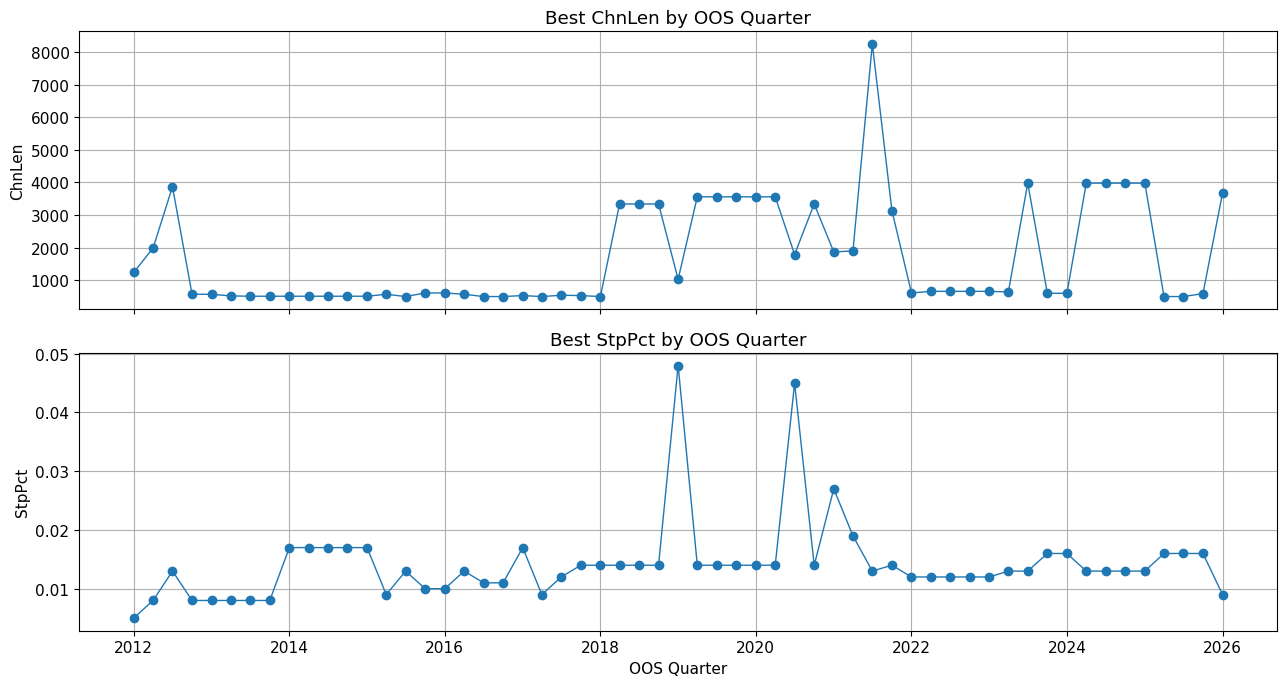

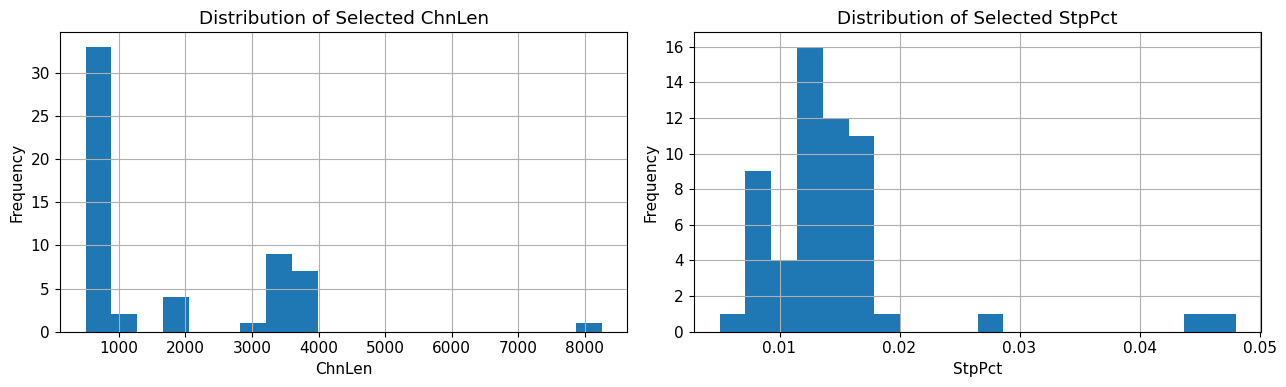

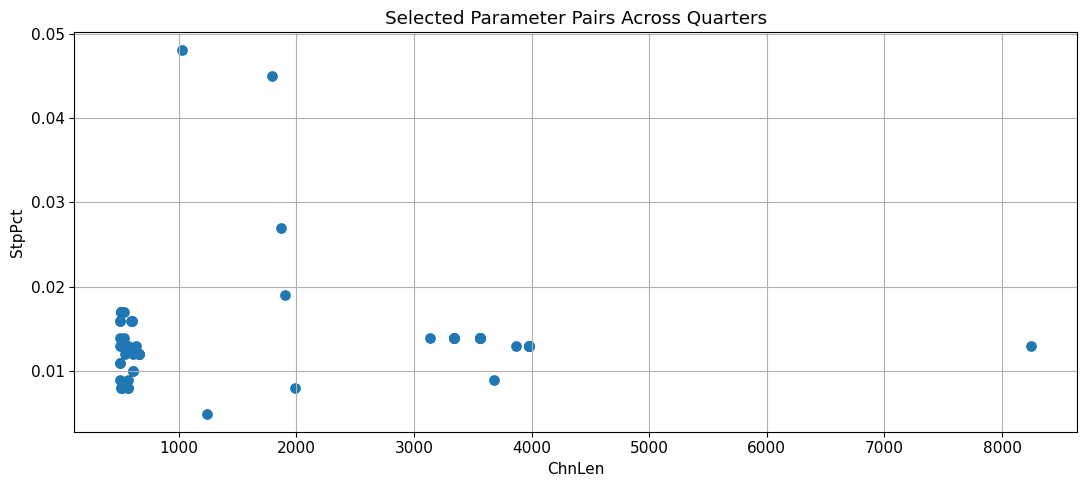

,Metric,Value
0,Median ChnLen,640.000000
1,Mean ChnLen,1722.631579
2,Min ChnLen,500.000000
3,Max ChnLen,8250.000000
4,Median StpPct,0.013000
5,Mean StpPct,0.014263
6,Min StpPct,0.005000
7,Max StpPct,0.048000
8,Median absolute quarterly ChnLen change,30.000000
9,Median absolute quarterly StpPct change,0.000000


In [31]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(params["q_start"], params["best_L"], marker="o", linewidth=1)
axes[0].set_title("Best ChnLen by OOS Quarter")
axes[0].set_ylabel("ChnLen")
axes[1].plot(params["q_start"], params["best_S"], marker="o", linewidth=1)
axes[1].set_title("Best StpPct by OOS Quarter")
axes[1].set_ylabel("StpPct")
axes[1].set_xlabel("OOS Quarter")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_parameter_paths.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(params["best_L"], bins=20)
axes[0].set_title("Distribution of Selected ChnLen")
axes[0].set_xlabel("ChnLen")
axes[0].set_ylabel("Frequency")
axes[1].hist(params["best_S"], bins=20)
axes[1].set_title("Distribution of Selected StpPct")
axes[1].set_xlabel("StpPct")
axes[1].set_ylabel("Frequency")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_parameter_distributions.png")
plt.show()

fig, ax = plt.subplots()
sc = ax.scatter(params["best_L"], params["best_S"], s=45)
ax.set_title("Selected Parameter Pairs Across Quarters")
ax.set_xlabel("ChnLen")
ax.set_ylabel("StpPct")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_selected_parameter_pairs.png")
plt.show()

param_summary = pd.DataFrame({
    "Metric": [
        "Median ChnLen", "Mean ChnLen", "Min ChnLen", "Max ChnLen",
        "Median StpPct", "Mean StpPct", "Min StpPct", "Max StpPct",
        "Median absolute quarterly ChnLen change", "Median absolute quarterly StpPct change"
    ],
    "Value": [
        params["best_L"].median(), params["best_L"].mean(), params["best_L"].min(), params["best_L"].max(),
        params["best_S"].median(), params["best_S"].mean(), params["best_S"].min(), params["best_S"].max(),
        params["param_turnover_L"].median(), params["param_turnover_S"].median()
    ]
})
param_summary.to_csv(TABLE_DIR / "parameter_stability_summary.csv", index=False)
display(param_summary)

## 9. In-Sample Objective vs. Out-of-Sample Realization

The optimization objective is computed on the in-sample window, while the actual quarter profit is realized out-of-sample. The relationship between `is_npdd` and `os_npdd` gives a quarter-level view of how much the in-sample ranking translated into subsequent performance.

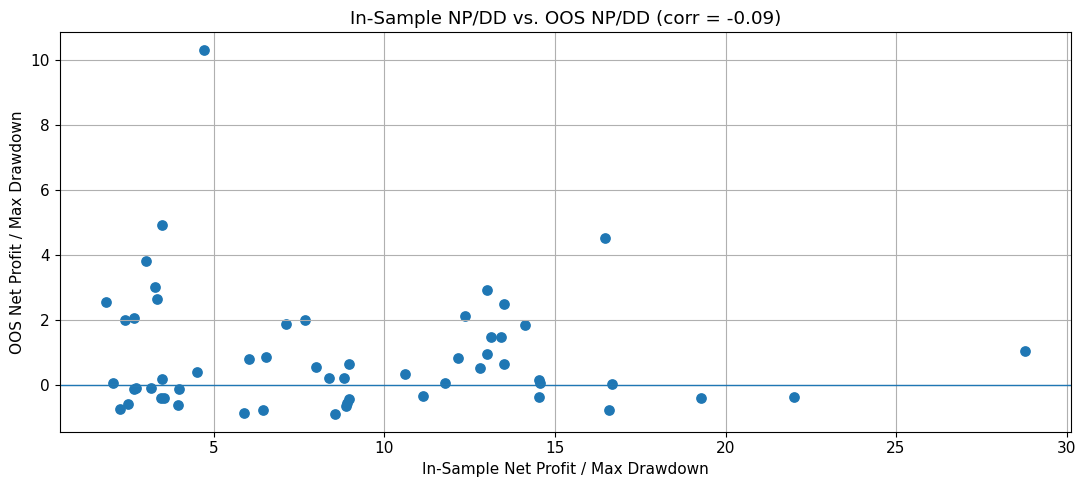

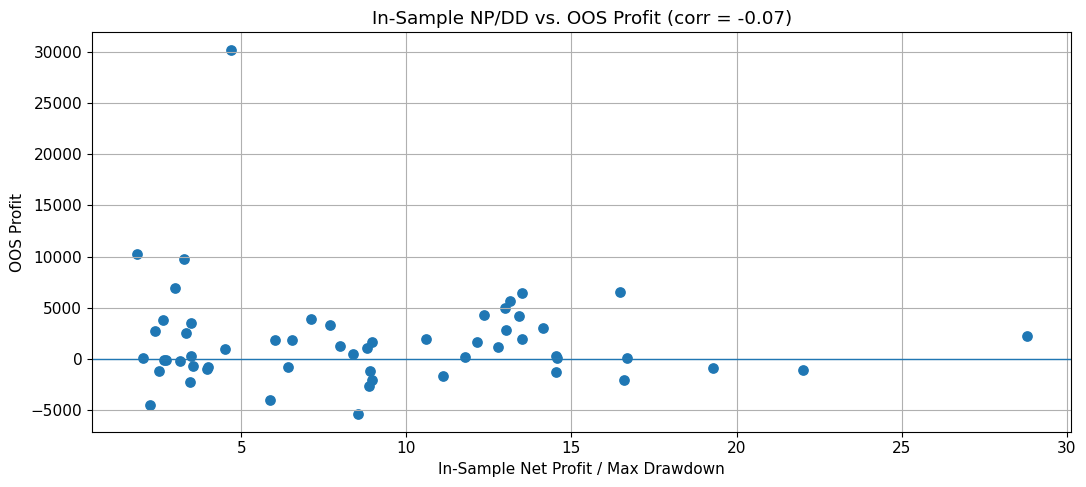

,Metric,Value
0,Correlation: IS NP/DD vs OOS NP/DD,-0.092286
1,Correlation: IS NP/DD vs OOS profit,-0.072866


In [32]:
valid = params.replace([np.inf, -np.inf], np.nan).dropna(subset=["is_npdd", "os_npdd", "os_profit"])
cor_is_os_npdd = valid["is_npdd"].corr(valid["os_npdd"]) if len(valid) > 2 else np.nan
cor_is_os_profit = valid["is_npdd"].corr(valid["os_profit"]) if len(valid) > 2 else np.nan

fig, ax = plt.subplots()
ax.scatter(valid["is_npdd"], valid["os_npdd"], s=45)
ax.axhline(0, linewidth=1)
ax.set_title(f"In-Sample NP/DD vs. OOS NP/DD (corr = {cor_is_os_npdd:.2f})")
ax.set_xlabel("In-Sample Net Profit / Max Drawdown")
ax.set_ylabel("OOS Net Profit / Max Drawdown")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_is_npdd_vs_oos_npdd.png")
plt.show()

fig, ax = plt.subplots()
ax.scatter(valid["is_npdd"], valid["os_profit"], s=45)
ax.axhline(0, linewidth=1)
ax.set_title(f"In-Sample NP/DD vs. OOS Profit (corr = {cor_is_os_profit:.2f})")
ax.set_xlabel("In-Sample Net Profit / Max Drawdown")
ax.set_ylabel("OOS Profit")
fig.tight_layout()
fig.savefig(FIG_DIR / "08_is_npdd_vs_oos_profit.png")
plt.show()

translation = pd.DataFrame({
    "Metric": ["Correlation: IS NP/DD vs OOS NP/DD", "Correlation: IS NP/DD vs OOS profit"],
    "Value": [cor_is_os_npdd, cor_is_os_profit]
})
translation.to_csv(TABLE_DIR / "is_to_oos_translation.csv", index=False)
display(translation)

## 10. Trade-Level Diagnostics

Trend-following systems often have a lower win rate but larger average winners than losers. The following diagnostics show whether the PL strategy follows this expected payoff profile and whether performance is dominated by long or short trades.

,side_label,trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_holding_minutes,avg_holding_bars
0,Long,310,66376.66,214.118258,-145.545,0.412903,2612.580645,79.283871
1,Short,310,34451.53,111.133968,-159.720,0.406452,2818.193548,83.000000


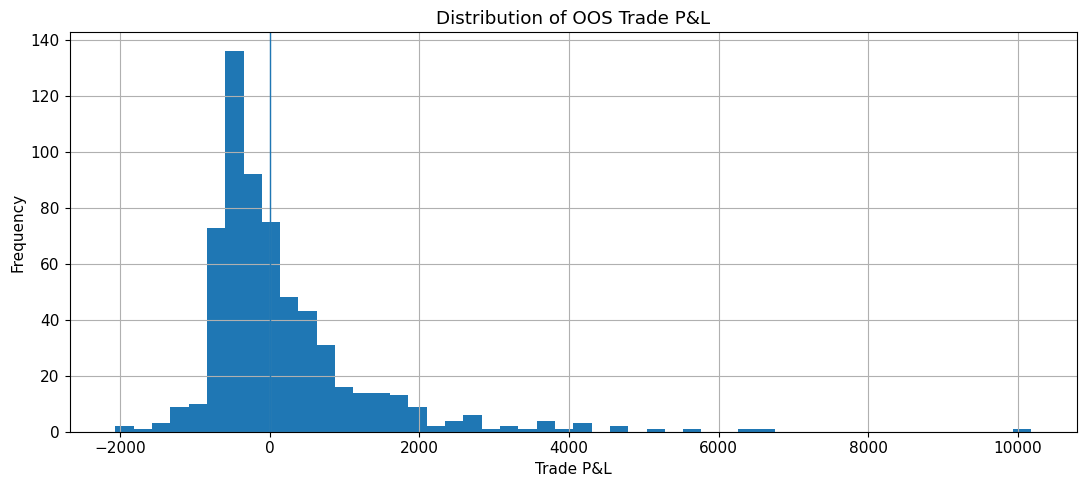

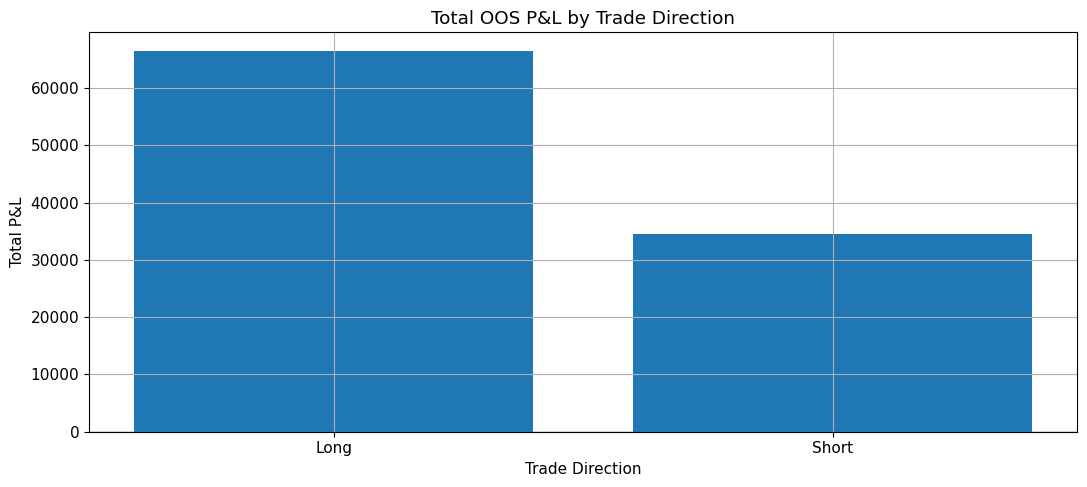

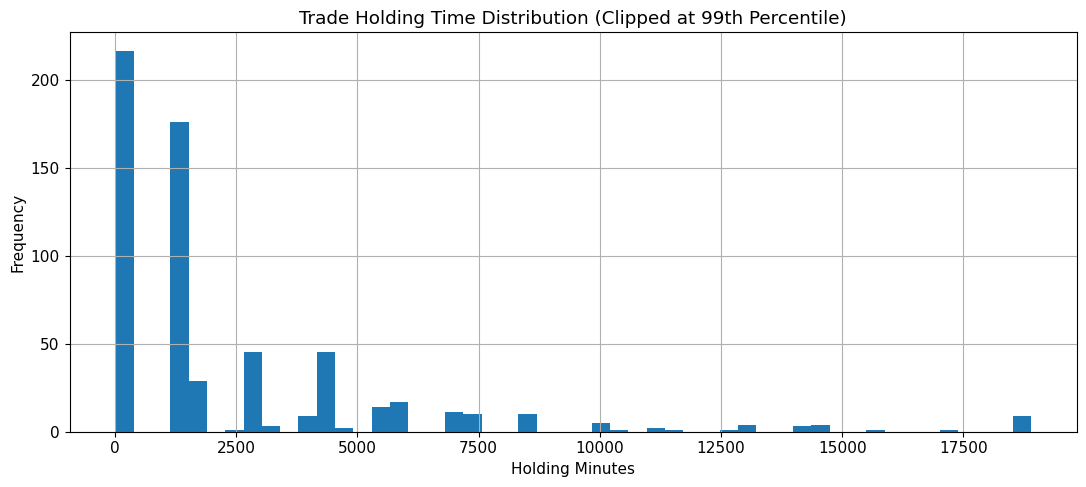

In [33]:
by_side = trades.groupby("side_label").agg(
    trades=("pnl", "count"),
    total_pnl=("pnl", "sum"),
    avg_pnl=("pnl", "mean"),
    median_pnl=("pnl", "median"),
    win_rate=("pnl", lambda x: (x > 0).mean()),
    avg_holding_minutes=("holding_minutes", "mean"),
    avg_holding_bars=("holding_bars", "mean"),
).reset_index()
by_side.to_csv(TABLE_DIR / "trade_summary_by_side.csv", index=False)
display(by_side)

fig, ax = plt.subplots()
ax.hist(trades["pnl"], bins=50)
ax.axvline(0, linewidth=1)
ax.set_title("Distribution of OOS Trade P&L")
ax.set_xlabel("Trade P&L")
ax.set_ylabel("Frequency")
fig.tight_layout()
fig.savefig(FIG_DIR / "09_trade_pnl_distribution.png")
plt.show()

fig, ax = plt.subplots()
side_pnl = by_side.set_index("side_label")["total_pnl"]
ax.bar(side_pnl.index, side_pnl.values)
ax.axhline(0, linewidth=1)
ax.set_title("Total OOS P&L by Trade Direction")
ax.set_xlabel("Trade Direction")
ax.set_ylabel("Total P&L")
fig.tight_layout()
fig.savefig(FIG_DIR / "10_trade_pnl_by_side.png")
plt.show()

fig, ax = plt.subplots()
ax.hist(trades["holding_minutes"].clip(upper=trades["holding_minutes"].quantile(0.99)), bins=50)
ax.set_title("Trade Holding Time Distribution (Clipped at 99th Percentile)")
ax.set_xlabel("Holding Minutes")
ax.set_ylabel("Frequency")
fig.tight_layout()
fig.savefig(FIG_DIR / "11_holding_time_distribution.png")
plt.show()

## 11. Risk Diagnostics: Daily Returns, Tail Risk, and Rolling Windows

This section evaluates risk using daily equity observations. The statistics below should be interpreted as strategy-account diagnostics rather than contract-level return estimates.

,Metric,Value
0,Daily VaR 95%,-0.004230
1,Daily CVaR 95%,-0.005639
2,Daily return skewness,2.776944
3,Daily return excess kurtosis,19.038980


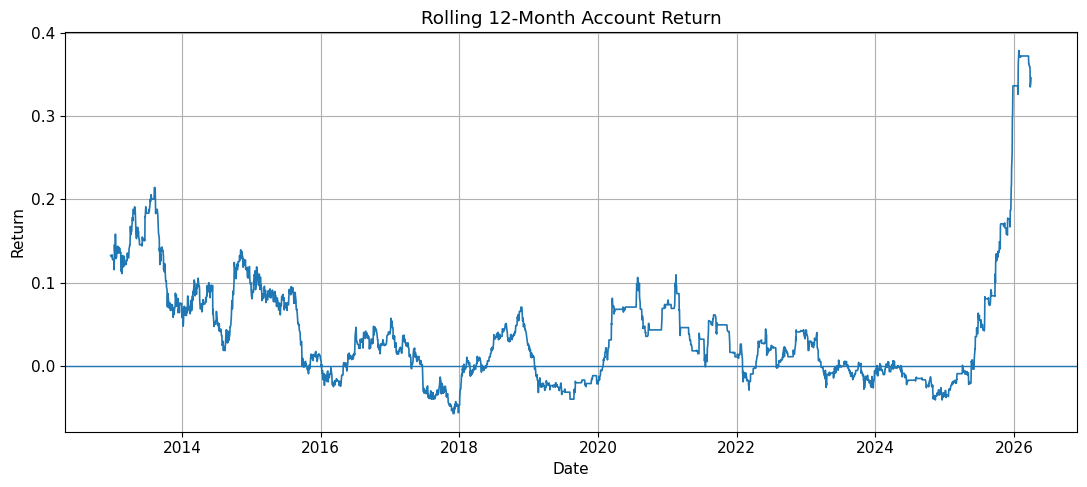

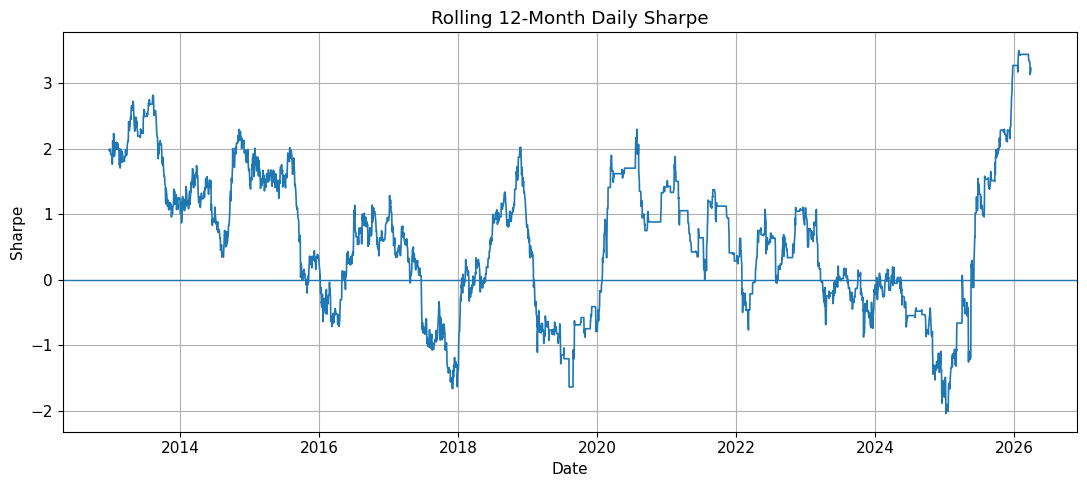

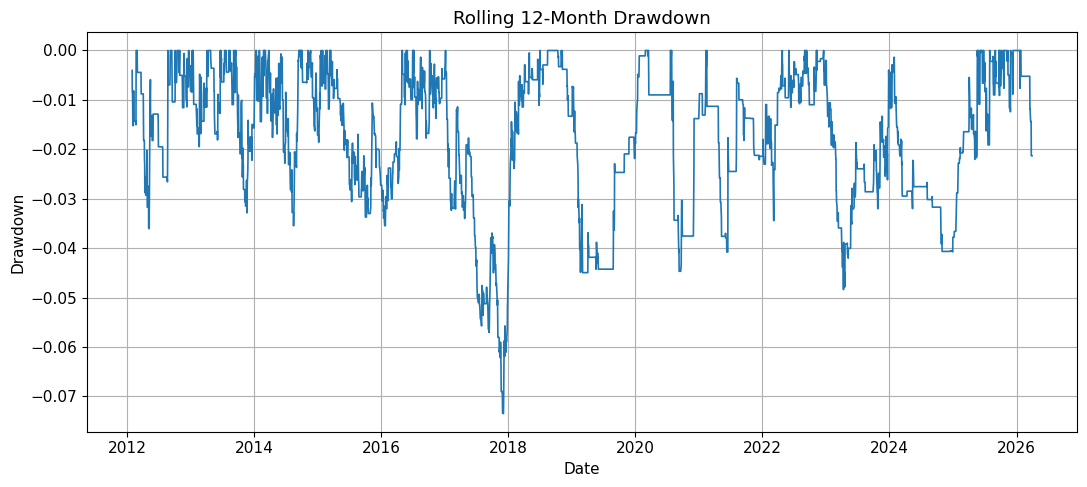

In [34]:
var_95 = daily_ret.quantile(0.05) if len(daily_ret) else np.nan
cvar_95 = daily_ret[daily_ret <= var_95].mean() if len(daily_ret) else np.nan
skew = daily_ret.skew() if len(daily_ret) else np.nan
kurt = daily_ret.kurtosis() if len(daily_ret) else np.nan

risk_summary = pd.DataFrame({
    "Metric": ["Daily VaR 95%", "Daily CVaR 95%", "Daily return skewness", "Daily return excess kurtosis"],
    "Value": [var_95, cvar_95, skew, kurt]
})
risk_summary.to_csv(TABLE_DIR / "daily_risk_summary.csv", index=False)
display(risk_summary)

rolling_252_return = daily_equity.pct_change(252)
rolling_252_vol = daily_ret.rolling(252).std() * np.sqrt(252)
rolling_252_sharpe = daily_ret.rolling(252).mean() / daily_ret.rolling(252).std() * np.sqrt(252)
rolling_252_dd = daily_equity / daily_equity.rolling(252, min_periods=20).max() - 1

fig, ax = plt.subplots()
ax.plot(rolling_252_return.index, rolling_252_return, linewidth=1.2)
ax.axhline(0, linewidth=1)
ax.set_title("Rolling 12-Month Account Return")
ax.set_xlabel("Date")
ax.set_ylabel("Return")
fig.tight_layout()
fig.savefig(FIG_DIR / "12_rolling_12m_return.png")
plt.show()

fig, ax = plt.subplots()
ax.plot(rolling_252_sharpe.index, rolling_252_sharpe, linewidth=1.2)
ax.axhline(0, linewidth=1)
ax.set_title("Rolling 12-Month Daily Sharpe")
ax.set_xlabel("Date")
ax.set_ylabel("Sharpe")
fig.tight_layout()
fig.savefig(FIG_DIR / "13_rolling_12m_sharpe.png")
plt.show()

fig, ax = plt.subplots()
ax.plot(rolling_252_dd.index, rolling_252_dd, linewidth=1.2)
ax.set_title("Rolling 12-Month Drawdown")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
fig.tight_layout()
fig.savefig(FIG_DIR / "14_rolling_12m_drawdown.png")
plt.show()

## 12. Monthly and Annual Performance Attribution

The following tables summarize calendar-year and calendar-month performance from the daily equity series. These views are useful for presentation because they show the stability of performance over time.

,pnl,avg_daily_return,vol_daily_return,trading_days,annualized_sharpe,ending_equity
Year,,,,,,
2012,12749.470,0.000473,0.003989,258,1.882894,112749.470
2013,8436.720,0.000287,0.003724,258,1.221790,121186.190
2014,12767.335,0.000395,0.003625,258,1.729052,133953.525
2015,1440.720,0.000045,0.002476,258,0.285403,135394.245
2016,5074.220,0.000146,0.002696,258,0.861059,140468.465
2017,-5567.730,-0.000155,0.002287,257,-1.074096,134900.735
2018,5026.100,0.000144,0.002010,258,1.135525,139926.835
2019,-1718.570,-0.000046,0.001719,258,-0.428766,138208.265
2020,9665.895,0.000266,0.003178,259,1.328919,147874.160


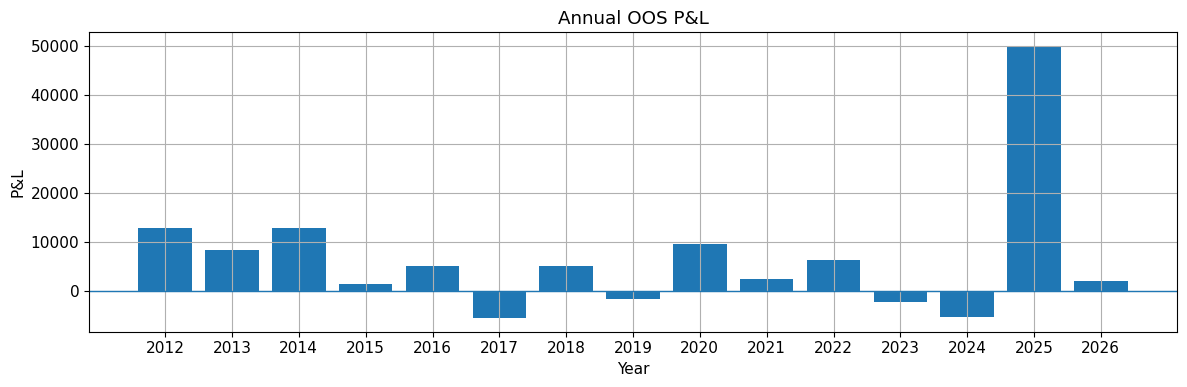

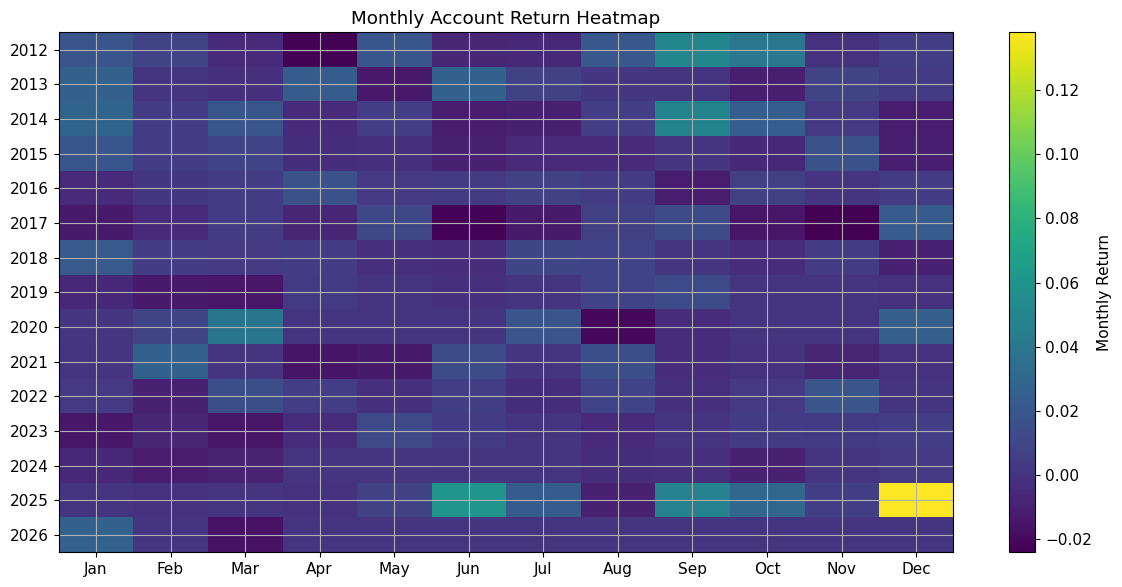

In [35]:
# Daily account P&L and returns.
daily = pd.DataFrame({"Equity": daily_equity})
daily["PnL"] = daily["Equity"].diff().fillna(0)
daily["Return"] = daily["Equity"].pct_change().fillna(0)
daily["Year"] = daily.index.year
daily["Month"] = daily.index.month

annual = daily.groupby("Year").agg(
    pnl=("PnL", "sum"),
    avg_daily_return=("Return", "mean"),
    vol_daily_return=("Return", "std"),
    trading_days=("Return", "count"),
)
annual["annualized_sharpe"] = annual["avg_daily_return"] / annual["vol_daily_return"] * np.sqrt(252)
annual["ending_equity"] = daily.groupby("Year")["Equity"].last()
annual.to_csv(TABLE_DIR / "annual_performance.csv")
display(annual)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(annual.index.astype(str), annual["pnl"])
ax.axhline(0, linewidth=1)
ax.set_title("Annual OOS P&L")
ax.set_xlabel("Year")
ax.set_ylabel("P&L")
fig.tight_layout()
fig.savefig(FIG_DIR / "15_annual_pnl.png")
plt.show()

monthly = daily.groupby(["Year", "Month"]).agg(pnl=("PnL", "sum"), ret=("Return", lambda x: (1 + x).prod() - 1)).reset_index()
monthly_pivot = monthly.pivot(index="Year", columns="Month", values="ret")
monthly_pivot.to_csv(TABLE_DIR / "monthly_return_matrix.csv")

def month_name(m):
    return pd.Timestamp(year=2000, month=int(m), day=1).strftime("%b")
monthly_plot = monthly_pivot.copy()
monthly_plot.columns = [month_name(c) for c in monthly_plot.columns]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(monthly_plot.fillna(0).values, aspect="auto")
ax.set_xticks(range(len(monthly_plot.columns)))
ax.set_xticklabels(monthly_plot.columns)
ax.set_yticks(range(len(monthly_plot.index)))
ax.set_yticklabels(monthly_plot.index)
ax.set_title("Monthly Account Return Heatmap")
fig.colorbar(im, ax=ax, label="Monthly Return")
fig.tight_layout()
fig.savefig(FIG_DIR / "16_monthly_return_heatmap.png")
plt.show()

## 13. Drawdown Episode Analysis

This section identifies the major underwater periods in the out-of-sample equity curve. A drawdown episode starts when equity falls below its previous high and ends when the equity recovers to a new high.

,start,trough,recovery,max_drawdown,days_to_trough,days_to_recovery
245,2017-01-05 11:25:00,2017-12-04 12:05:00,2020-03-12 11:40:00,-10740.050,333,1162.0
298,2022-12-01 10:10:00,2025-05-19 12:05:00,2025-06-18 09:40:00,-10024.715,900,929.0
266,2020-07-28 12:00:00,2020-09-22 08:45:00,2021-02-10 08:25:00,-6864.350,55,196.0
274,2021-02-15 12:55:00,2021-06-10 12:05:00,2022-06-02 12:05:00,-6343.405,114,471.0
391,2026-01-26 10:20:00,2026-03-27 09:50:00,NaT,-5580.810,59,NaN
229,2015-03-17 09:25:00,2015-10-16 10:05:00,2016-07-01 08:25:00,-5311.065,213,471.0
160,2014-06-04 09:00:00,2014-08-15 12:00:00,2014-09-12 10:45:00,-5134.130,72,100.0
107,2013-09-18 09:40:00,2013-11-21 10:05:00,2014-01-10 10:10:00,-4269.480,64,114.0
306,2025-06-26 08:50:00,2025-07-30 09:50:00,2025-07-31 08:25:00,-4238.200,34,34.0
6,2012-02-23 09:00:00,2012-05-08 08:55:00,2012-09-06 09:20:00,-4235.395,74,196.0


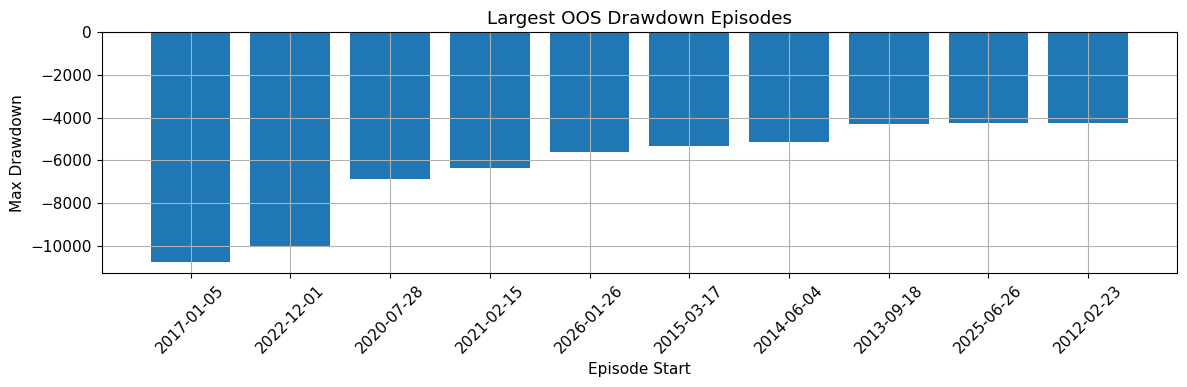

In [36]:
def drawdown_episodes(df):
    episodes = []
    in_dd = False
    start_idx = None
    trough_idx = None
    trough_dd = 0.0

    for i, row in df.iterrows():
        dd = row["Drawdown"]
        if dd < 0 and not in_dd:
            in_dd = True
            start_idx = i
            trough_idx = i
            trough_dd = dd
        elif dd < 0 and in_dd:
            if dd < trough_dd:
                trough_dd = dd
                trough_idx = i
        elif dd == 0 and in_dd:
            end_idx = i
            episodes.append({
                "start": df.loc[start_idx, "DateTime"],
                "trough": df.loc[trough_idx, "DateTime"],
                "recovery": df.loc[end_idx, "DateTime"],
                "max_drawdown": trough_dd,
                "days_to_trough": (df.loc[trough_idx, "DateTime"] - df.loc[start_idx, "DateTime"]).days,
                "days_to_recovery": (df.loc[end_idx, "DateTime"] - df.loc[start_idx, "DateTime"]).days,
            })
            in_dd = False

    if in_dd:
        end_idx = len(df) - 1
        episodes.append({
            "start": df.loc[start_idx, "DateTime"],
            "trough": df.loc[trough_idx, "DateTime"],
            "recovery": pd.NaT,
            "max_drawdown": trough_dd,
            "days_to_trough": (df.loc[trough_idx, "DateTime"] - df.loc[start_idx, "DateTime"]).days,
            "days_to_recovery": np.nan,
        })
    return pd.DataFrame(episodes)

dd_episodes = drawdown_episodes(equity)
top_dd = dd_episodes.sort_values("max_drawdown").head(10)
top_dd.to_csv(TABLE_DIR / "top_drawdown_episodes.csv", index=False)
display(top_dd)

fig, ax = plt.subplots(figsize=(12, 4))
plot_dd = top_dd.sort_values("max_drawdown")
labels = plot_dd["start"].dt.strftime("%Y-%m-%d")
ax.bar(labels, plot_dd["max_drawdown"])
ax.set_title("Largest OOS Drawdown Episodes")
ax.set_xlabel("Episode Start")
ax.set_ylabel("Max Drawdown")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIG_DIR / "17_largest_drawdown_episodes.png")
plt.show()

## 14. Bootstrap Diagnostics for Trade Expectancy

The bootstrap is a diagnostic tool that resamples the observed out-of-sample trades to estimate uncertainty around trade expectancy and profit factor. It does not assume that trades are independent in the actual market process; it is used here as a descriptive robustness check.

,Diagnostic,Observed,Bootstrap 2.5%,Bootstrap 50%,Bootstrap 97.5%
0,Trade expectancy,162.626113,77.427640,161.911379,251.991354
1,Profit factor,1.591775,1.262560,1.588351,1.974935
2,Total trade P&L,100828.190000,48005.136875,100385.055000,156234.639750


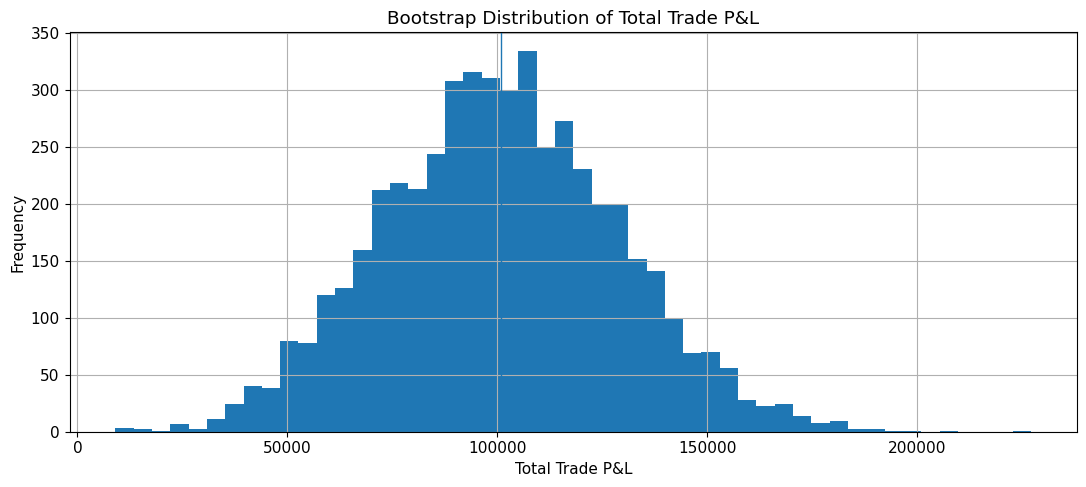

In [37]:
rng = np.random.default_rng(5360)
B = 5000
trade_pnls = trades["pnl"].to_numpy()

if len(trade_pnls) > 0:
    boot_mean = np.empty(B)
    boot_pf = np.empty(B)
    boot_final_pnl = np.empty(B)
    for b in range(B):
        sample = rng.choice(trade_pnls, size=len(trade_pnls), replace=True)
        boot_mean[b] = sample.mean()
        gp = sample[sample > 0].sum()
        gl = sample[sample < 0].sum()
        boot_pf[b] = gp / abs(gl) if gl != 0 else np.nan
        boot_final_pnl[b] = sample.sum()

    boot_summary = pd.DataFrame({
        "Diagnostic": ["Trade expectancy", "Profit factor", "Total trade P&L"],
        "Observed": [trade_pnls.mean(), profit_factor, trade_pnls.sum()],
        "Bootstrap 2.5%": [np.nanpercentile(boot_mean, 2.5), np.nanpercentile(boot_pf, 2.5), np.nanpercentile(boot_final_pnl, 2.5)],
        "Bootstrap 50%": [np.nanpercentile(boot_mean, 50), np.nanpercentile(boot_pf, 50), np.nanpercentile(boot_final_pnl, 50)],
        "Bootstrap 97.5%": [np.nanpercentile(boot_mean, 97.5), np.nanpercentile(boot_pf, 97.5), np.nanpercentile(boot_final_pnl, 97.5)],
    })
else:
    boot_summary = pd.DataFrame()

boot_summary.to_csv(TABLE_DIR / "bootstrap_trade_diagnostics.csv", index=False)
display(boot_summary)

fig, ax = plt.subplots()
ax.hist(boot_final_pnl, bins=50)
ax.axvline(trade_pnls.sum(), linewidth=1)
ax.set_title("Bootstrap Distribution of Total Trade P&L")
ax.set_xlabel("Total Trade P&L")
ax.set_ylabel("Frequency")
fig.tight_layout()
fig.savefig(FIG_DIR / "18_bootstrap_total_trade_pnl.png")
plt.show()

## 15. Profit Concentration and Trade Contribution

Trend-following systems often generate a large portion of total P&L from a relatively small number of large winning trades. This section quantifies that concentration using the reconstructed out-of-sample trade table.

,Top trade group,Number of trades,P&L contribution,Share of net P&L,Share of gross profit
0,Top 1%,7,43546.750,0.431891,0.160564
1,Top 5%,31,117949.510,1.169807,0.434899
2,Top 10%,62,171585.215,1.701758,0.632663
3,Top 20%,124,232220.900,2.303135,0.856237


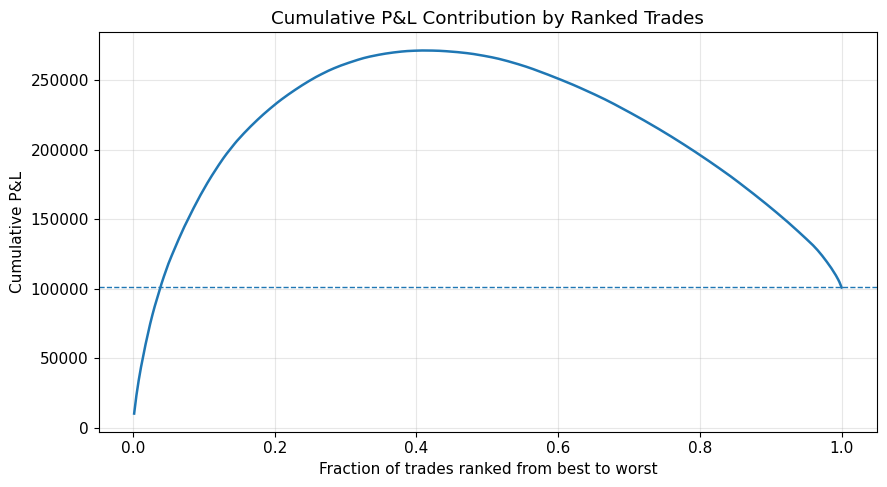

In [38]:
trade_ranked = trades.sort_values("pnl", ascending=False).reset_index(drop=True)
trade_ranked["rank"] = np.arange(1, len(trade_ranked) + 1)
trade_ranked["rank_pct"] = trade_ranked["rank"] / len(trade_ranked)
trade_ranked["cum_pnl"] = trade_ranked["pnl"].cumsum()

gross_profit = trades.loc[trades["pnl"] > 0, "pnl"].sum()
gross_loss = -trades.loc[trades["pnl"] < 0, "pnl"].sum()
net_profit = trades["pnl"].sum()

concentration_rows = []
for share in [0.01, 0.05, 0.10, 0.20]:
    k = max(1, int(np.ceil(len(trades) * share)))
    top_pnl = trade_ranked.head(k)["pnl"].sum()
    concentration_rows.append({
        "Top trade group": f"Top {int(share * 100)}%",
        "Number of trades": k,
        "P&L contribution": top_pnl,
        "Share of net P&L": safe_div(top_pnl, net_profit),
        "Share of gross profit": safe_div(top_pnl, gross_profit),
    })

profit_concentration = pd.DataFrame(concentration_rows)
profit_concentration.to_csv(TABLE_DIR / "profit_concentration.csv", index=False)
display(profit_concentration)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(trade_ranked["rank_pct"], trade_ranked["cum_pnl"], linewidth=1.8)
ax.axhline(net_profit, linestyle="--", linewidth=1)
ax.set_title("Cumulative P&L Contribution by Ranked Trades")
ax.set_xlabel("Fraction of trades ranked from best to worst")
ax.set_ylabel("Cumulative P&L")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "trade_contribution_curve.png", dpi=200, bbox_inches="tight")
plt.show()

## 16. Trade-Order Monte Carlo Path-Risk Diagnostic

The realized set of trades determines total P&L, but drawdown also depends on sequencing. The following diagnostic randomly permutes the order of realized trade P&L observations to compare the realized path drawdown with alternative trade-order paths.

,Metric,2.5%,Median,97.5%,Realized
0,final_equity,200828.190000,200828.190000,200828.190000,200828.190000
1,max_drawdown,-17286.441000,-10183.265000,-6793.967500,-9764.050000
2,npdd,5.832791,9.901362,14.840841,10.326472


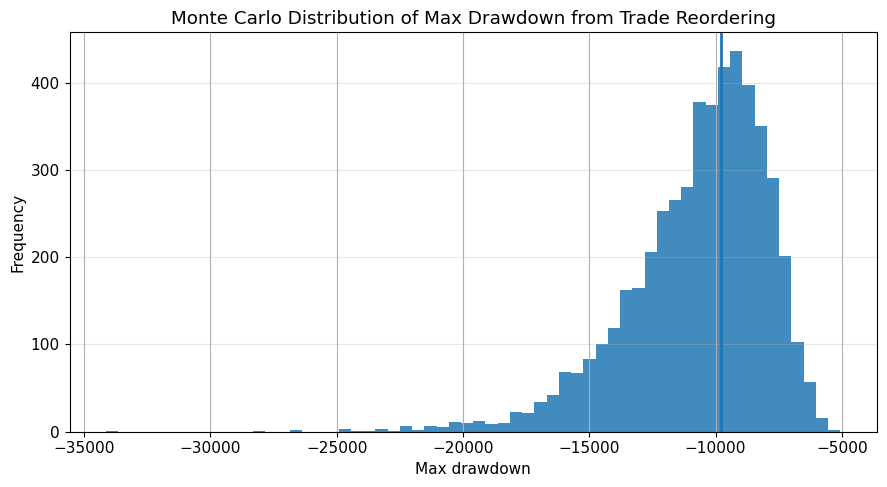

In [39]:
# Initial capital used in the WFO equity curve
INITIAL_EQUITY = 100000.0

def trade_order_monte_carlo(pnl, initial_equity=INITIAL_EQUITY, n_sims=5000, seed=5360):
    local_rng = np.random.default_rng(seed)
    pnl = np.asarray(pnl, dtype=float)

    rows = []
    for _ in range(n_sims):
        permuted = local_rng.permutation(pnl)
        eq_path = initial_equity + np.cumsum(permuted)
        running_max = np.maximum.accumulate(np.r_[initial_equity, eq_path])[1:]
        dd = eq_path - running_max

        max_dd = dd.min()
        rows.append({
            "final_equity": eq_path[-1],
            "max_drawdown": max_dd,
            "npdd": safe_div(eq_path[-1] - initial_equity, abs(max_dd)),
        })

    return pd.DataFrame(rows)

mc = trade_order_monte_carlo(trades["pnl"], initial_equity=INITIAL_EQUITY, n_sims=5000)

realized_trade_equity = INITIAL_EQUITY + trades["pnl"].cumsum()
realized_trade_running_max = np.maximum.accumulate(
    np.r_[INITIAL_EQUITY, realized_trade_equity]
)[1:]
realized_trade_dd = realized_trade_equity - realized_trade_running_max
realized_trade_maxdd = realized_trade_dd.min()
realized_trade_npdd = safe_div(
    realized_trade_equity.iloc[-1] - INITIAL_EQUITY,
    abs(realized_trade_maxdd)
)

mc_summary = mc.quantile([0.025, 0.50, 0.975]).T.reset_index()
mc_summary.columns = ["Metric", "2.5%", "Median", "97.5%"]
mc_summary["Realized"] = [
    realized_trade_equity.iloc[-1],
    realized_trade_maxdd,
    realized_trade_npdd,
]

mc_summary.to_csv(TABLE_DIR / "trade_order_monte_carlo_summary.csv", index=False)
display(mc_summary)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(mc["max_drawdown"], bins=60, alpha=0.85)
ax.axvline(realized_trade_maxdd, linewidth=2)
ax.set_title("Monte Carlo Distribution of Max Drawdown from Trade Reordering")
ax.set_xlabel("Max drawdown")
ax.set_ylabel("Frequency")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "trade_order_monte_carlo_drawdown.png", dpi=200, bbox_inches="tight")
plt.show()

## 17. Presentation-Ready Interpretation

The following points are generated from the observed output files and can be used directly in the primary-market result section of the presentation.

In [43]:
def find_col(df, candidates, required=True, label="column"):
    lower_map = {str(c).lower().strip(): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().strip()
        if key in lower_map:
            return lower_map[key]
    if required:
        raise ValueError(
            f"Could not find {label}. Tried {candidates}. "
            f"Available columns: {list(df.columns)}"
        )
    return None

# Identify required columns
equity_col = find_col(
    equity,
    ["equity", "Equity", "cum_equity", "os_equity", "account_equity", "capital"],
    label="equity column"
)

datetime_col = find_col(
    equity,
    ["DateTime", "datetime", "date_time", "timestamp", "time", "date"],
    required=False,
    label="datetime column"
)

# Ensure equity series is numeric
equity_series = pd.to_numeric(equity[equity_col], errors="coerce").dropna()

initial_equity = float(equity_series.iloc[0])
final_equity = float(equity_series.iloc[-1])
total_profit = final_equity - initial_equity

running_max = equity_series.cummax()
drawdown_series = equity_series - running_max
worst_dd = float(drawdown_series.min())
np_over_dd = total_profit / abs(worst_dd) if worst_dd != 0 else np.nan

# OOS date range
if datetime_col is not None:
    dt_series = pd.to_datetime(equity[datetime_col], errors="coerce").dropna()
    if len(dt_series) > 0:
        start_date = dt_series.min().date()
        end_date = dt_series.max().date()
    else:
        start_date = "N/A"
        end_date = "N/A"
else:
    start_date = "N/A"
    end_date = "N/A"

# Trade P&L column
trade_pnl_col = find_col(
    trades,
    ["pnl", "trade_pnl", "profit", "net_profit", "TradePnL", "PL"],
    label="trade P&L column"
)

trade_pnl = pd.to_numeric(trades[trade_pnl_col], errors="coerce").dropna()
n_trades = len(trade_pnl)

wins = trade_pnl[trade_pnl > 0]
losses = trade_pnl[trade_pnl < 0]

win_rate = len(wins) / len(trade_pnl) if len(trade_pnl) > 0 else np.nan
avg_win = wins.mean() if len(wins) > 0 else np.nan
avg_loss = losses.mean() if len(losses) > 0 else np.nan
profit_factor = wins.sum() / abs(losses.sum()) if len(losses) > 0 and losses.sum() != 0 else np.nan

# Quarterly stability
if "os_profit" in quarterly.columns:
    quarterly_profit_col = "os_profit"
else:
    quarterly_profit_col = find_col(
        quarterly,
        ["os_profit", "profit", "net_profit", "oos_profit", "quarter_profit"],
        label="quarterly OOS profit column"
    )

positive_quarters = int((pd.to_numeric(quarterly[quarterly_profit_col], errors="coerce") > 0).sum())
negative_quarters = int((pd.to_numeric(quarterly[quarterly_profit_col], errors="coerce") < 0).sum())

# Direction attribution if available
try:
    if len(by_side) > 0 and "total_pnl" in by_side.columns and "side_label" in by_side.columns:
        side_leader = by_side.sort_values("total_pnl", ascending=False).iloc[0]["side_label"]
    else:
        side_leader = "N/A"
except NameError:
    side_leader = "N/A"

bullets = [
    "Implementation: The primary-market analysis uses the close-only Channel WithDDControl engine implemented in Python with Numba acceleration.",
    f"Walk-forward design: The PL result covers {len(params)} out-of-sample quarters from {start_date} to {end_date}.",
    f"Performance: OOS equity increased from {initial_equity:,.0f} to {final_equity:,.0f}, corresponding to total OOS profit of {total_profit:,.0f}.",
    f"Risk: The worst OOS drawdown was {worst_dd:,.0f}, giving a Net Profit-to-Max Drawdown ratio of {np_over_dd:.2f}.",
    f"Trade profile: The strategy produced {n_trades} reconstructed OOS trades with a win rate of {win_rate:.1%} and a profit factor of {profit_factor:.2f}.",
    f"Payoff shape: Average winner was {avg_win:,.0f} versus average loser of {avg_loss:,.0f}, consistent with a trend-following payoff profile.",
    f"Quarterly stability: {positive_quarters} quarters were profitable and {negative_quarters} quarters were negative on an OOS basis.",
    f"Direction attribution: The larger contribution came from {str(side_leader).lower()} trades in this PL OOS sample.",
    "Parameter behavior: The selected ChnLen and StpPct values vary across quarters, indicating that the optimal trend-following horizon changes across market regimes.",
]

for bullet in bullets:
    print("– " + bullet)

with open(TABLE_DIR / "presentation_bullets.txt", "w") as f:
    for bullet in bullets:
        f.write("– " + bullet + "\n")

– Implementation: The primary-market analysis uses the close-only Channel WithDDControl engine implemented in Python with Numba acceleration.
– Walk-forward design: The PL result covers 57 out-of-sample quarters from 2012-01-03 to 2026-03-31.
– Performance: OOS equity increased from 100,000 to 200,828, corresponding to total OOS profit of 100,828.
– Risk: The worst OOS drawdown was -10,740, giving a Net Profit-to-Max Drawdown ratio of 9.39.
– Trade profile: The strategy produced 620 reconstructed OOS trades with a win rate of 41.0% and a profit factor of 1.59.
– Payoff shape: Average winner was 1,068 versus average loser of -466, consistent with a trend-following payoff profile.
– Quarterly stability: 36 quarters were profitable and 20 quarters were negative on an OOS basis.
– Direction attribution: The larger contribution came from long trades in this PL OOS sample.
– Parameter behavior: The selected ChnLen and StpPct values vary across quarters, indicating that the optimal trend-foll

## 18. Files Exported by This Notebook

The notebook exports all derived tables to `tables/primary_market/` and all figures to `figures/primary_market/`. These files can be used directly in the final presentation.

In [46]:
export_manifest = {
    "tables": sorted([p.name for p in TABLE_DIR.glob("*.csv")]) + sorted([p.name for p in TABLE_DIR.glob("*.txt")]),
    "figures": sorted([p.name for p in FIG_DIR.glob("*.png")]),
}

with open(TABLE_DIR / "export_manifest.json", "w") as f:
    json.dump(export_manifest, f, indent=2)

summary_export = pd.DataFrame({
    "Output Type": ["Tables and text files", "Figures", "Manifest file"],
    "Directory": [
        "tables/primary_market/",
        "figures/primary_market/",
        "tables/primary_market/export_manifest.json",
    ],
    "Number of Files": [
        len(export_manifest["tables"]),
        len(export_manifest["figures"]),
        1,
    ],
})

display(summary_export)

,Output Type,Directory,Number of Files
0,Tables and text files,tables/primary_market/,30
1,Figures,figures/primary_market/,32
2,Manifest file,tables/primary_market/export_manifest.json,1


## 19. Concise Conclusion

The PL primary-market walk-forward output shows a positive fully out-of-sample equity path with meaningful profit relative to drawdown. The trade distribution has the expected trend-following profile: the win rate is below one half, while average winners are substantially larger than average losers. Parameter choices vary over time, suggesting that PL trend-following behavior changes across regimes rather than being captured by a single fixed horizon.

The exported tables and figures from this notebook provide the core material for the primary-market algorithm section of the final presentation.